In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('battery_health_dataset.csv')

In [3]:
df.shape

(1200, 11)

In [4]:
df.head()

,Battery Age,Daily Usage Hours,Gaming User,Design Capacity,Cycle Count,CPU Usage,GPU Usage,Power Consumption,Average Temperature,Full Charge Capacity,Battery Health
0,5,9.797617,0,57884,1267,64.587764,43.887115,84.366245,35.645636,44961.935220,76.923383
1,9,7.101557,0,63824,1500,45.542182,36.534144,80.629042,31.782432,46619.665590,73.496153
2,9,10.085255,0,79414,1500,64.640516,52.238349,87.853504,32.122879,63343.419989,81.514041
3,5,7.946047,0,61142,1153,55.095724,30.535647,69.686012,30.371133,50407.438833,79.742100
4,7,9.628460,0,50956,1500,60.145756,36.749489,64.734123,27.536232,34757.377982,67.882552


In [6]:
df.dtypes

Battery Age               int64
Daily Usage Hours       float64
Gaming User               int64
Design Capacity           int64
Cycle Count               int64
CPU Usage               float64
GPU Usage               float64
Power Consumption       float64
Average Temperature     float64
Full Charge Capacity    float64
Battery Health          float64
dtype: object

In [6]:
df.rename(columns={
    "Battery Age": "Edad_Bateria",
    "Daily Usage Hours": "Horas_Uso_Diario",
    "Gaming User": "Usuario_Gamer",
    "Design Capacity": "Capacidad_Diseño",
    "Cycle Count": "Ciclos_Carga",
    "CPU Usage": "Uso_CPU",
    "GPU Usage": "Uso_GPU",
    "Power Consumption": "Consumo_Energia",
    "Average Temperature": "Temperatura_Promedio",
    "Full Charge Capacity": "Capacidad_Carga_Completa",
    "Battery Health": "Salud_Bateria"
}, inplace=True)

In [8]:
df.columns

Index(['Edad_Bateria', 'Horas_Uso_Diario', 'Usuario_Gamer', 'Capacidad_Diseño',
       'Ciclos_Carga', 'Uso_CPU', 'Uso_GPU', 'Consumo_Energia',
       'Temperatura_Promedio', 'Capacidad_Carga_Completa', 'Salud_Bateria'],
      dtype='object')

In [17]:
df.describe()

,Edad_Bateria,Horas_Uso_Diario,Usuario_Gamer,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,4.571667,6.435078,0.102500,62049.919167,993.813333,50.047021,37.081954,68.510005,30.483731,51798.125944,82.944518
std,2.831939,3.149664,0.303431,10096.807179,527.254899,18.859965,17.485642,21.213489,2.624044,11598.140456,9.924455
min,0.000000,1.002497,0.000000,45002.000000,0.000000,9.151884,5.000000,20.133013,22.908857,28181.020459,59.840266
25%,2.000000,3.722104,0.000000,53583.250000,530.500000,34.223028,24.084790,52.238214,28.758142,42865.372454,75.315849
50%,5.000000,6.322145,0.000000,61888.000000,1188.000000,50.097711,34.979134,67.399336,30.398357,51698.379658,81.461246
75%,7.000000,9.162563,0.000000,70734.750000,1500.000000,64.294947,46.615097,82.529511,32.231464,60403.354634,91.414773
max,9.000000,11.986722,1.000000,79959.000000,1500.000000,100.000000,98.339932,137.154936,39.934239,79263.000000,100.000000


In [8]:
duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


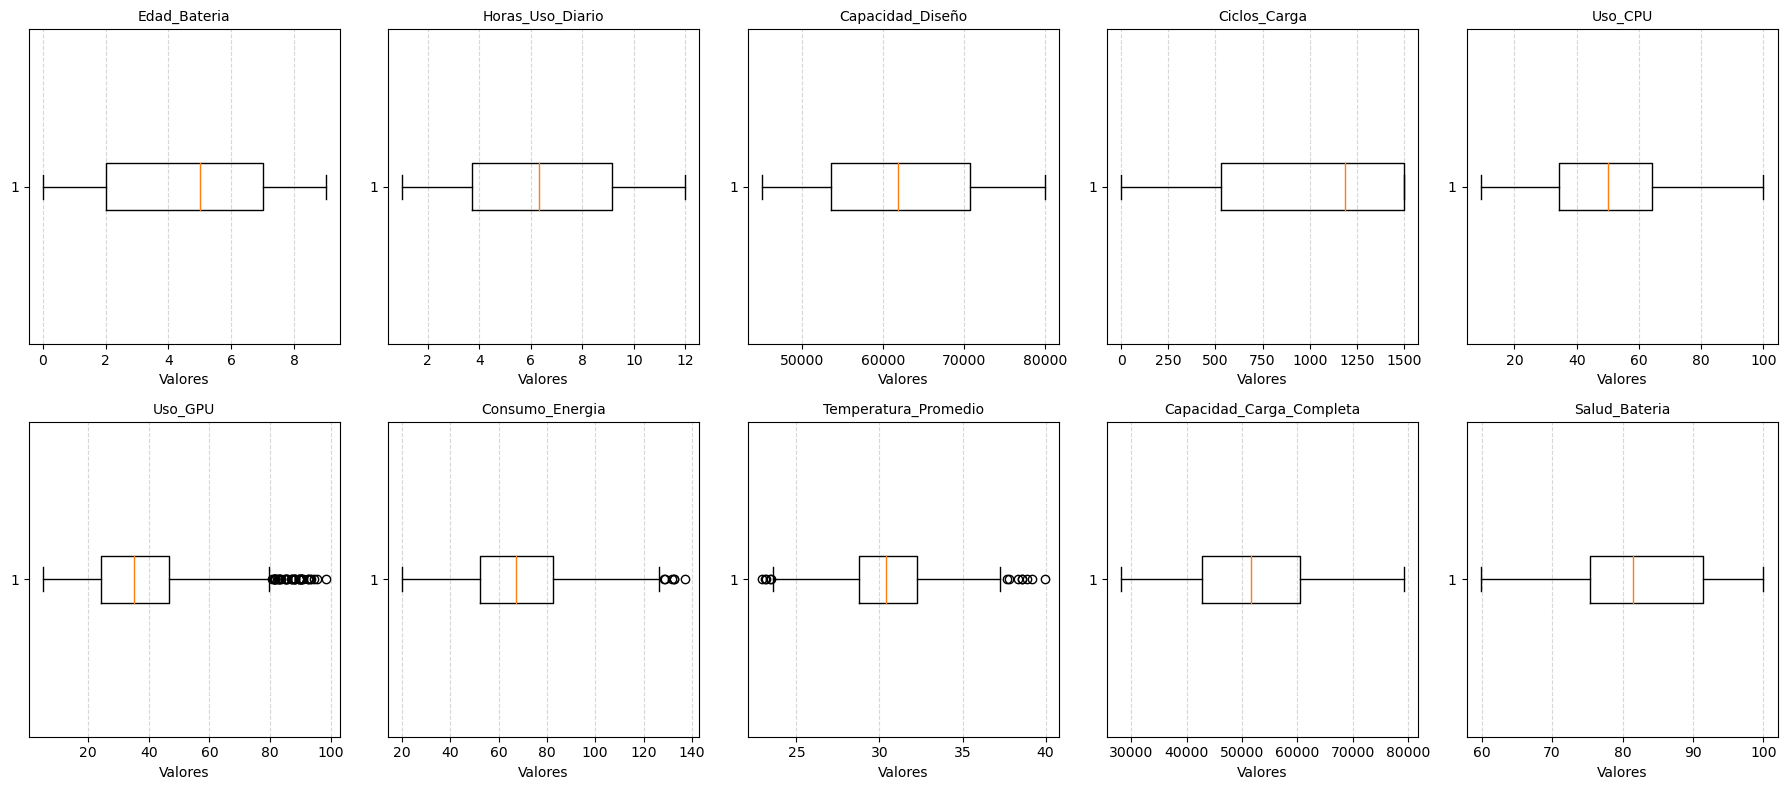

In [7]:
variables = [
    "Edad_Bateria",
    "Horas_Uso_Diario",
    "Capacidad_Diseño",
    "Ciclos_Carga",
    "Uso_CPU",
    "Uso_GPU",
    "Consumo_Energia",
    "Temperatura_Promedio",
    "Capacidad_Carga_Completa",
    "Salud_Bateria"
]

# Crear matriz de gráficos
fig, axes = plt.subplots( nrows=2,ncols=5,figsize=(18, 8))
axes = axes.flatten()
for i, variable in enumerate(variables):
    axes[i].boxplot(df[variable], vert=False)
    axes[i].set_title(variable, fontsize=10)
    axes[i].set_xlabel("Valores")
    axes[i].grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
def insertar_errores_bateria(df, porcentaje=0.10, random_state=42):
    # Copia para insertar errores
    df_error = df.copy()
    
    np.random.seed(random_state)
    # Número de filas afectadas
    n = int(len(df_error) * porcentaje)

    # 1. Valores nulos
    columnas_nulos = [
        "Uso_CPU",
        "Uso_GPU",
        "Temperatura_Promedio",
        "Salud_Bateria",
        "Consumo_Energia"
    ]

    for columna in columnas_nulos:
        filas = np.random.choice(df_error.index, n//2, replace=False)
        df_error.loc[filas, columna] = np.nan
   
    # 2. Temperaturas imposibles
    filas = np.random.choice(df_error.index,n,replace=False)
    df_error.loc[filas, "Temperatura_Promedio"] = np.random.choice([-20, -5, 120, 150],size=n)

    # 3. Edad de batería incorrecta
    filas = np.random.choice(df_error.index, n,replace=False)
    df_error.loc[filas, "Edad_Bateria"] = np.random.choice( [-3, 0, 40, 60], size=n )

    # 4. Ciclos de carga extremos
    filas = np.random.choice(df_error.index, n, replace=False )
    df_error.loc[ filas,  "Ciclos_Carga"] = np.random.randint(6000, 15000, size=n )

    # 5. Consumo de energía extremo
    filas = np.random.choice(df_error.index,n,replace=False)
    df_error.loc[filas, "Consumo_Energia"] = np.random.randint(300,800,size=n)

    # 6. Valores negativos imposibles
    filas = np.random.choice(df_error.index,n,replace=False)
    df_error.loc[filas,"Capacidad_Carga_Completa"] *= -1

    # 7. Porcentajes fuera de rango
    filas = np.random.choice(df_error.index,n,replace=False)
    df_error.loc[filas,"Uso_CPU"] = np.random.uniform(120,200,size=n)

    filas = np.random.choice(df_error.index,n,replace=False)
    df_error.loc[filas,  "Uso_GPU"] = np.random.uniform(120,180,size=n)

    # 8. Salud de batería incorrecta
    filas = np.random.choice(df_error.index, n, replace=False)
    df_error.loc[ filas, "Salud_Bateria"] = np.random.choice([-10, 0, 120, 150],size=n )

    # 10. Duplicados
    duplicados = df_error.sample(n=20,random_state=random_state)
    df_error = pd.concat([ df_error,duplicados],ignore_index=True)
    
    
    return df_error

In [10]:
df_sucio = insertar_errores_bateria(df)

In [11]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Edad_Bateria              1220 non-null   int64  
 1   Horas_Uso_Diario          1220 non-null   float64
 2   Usuario_Gamer             1220 non-null   int64  
 3   Capacidad_Diseño          1220 non-null   int64  
 4   Ciclos_Carga              1220 non-null   int64  
 5   Uso_CPU                   1142 non-null   float64
 6   Uso_GPU                   1164 non-null   float64
 7   Consumo_Energia           1166 non-null   float64
 8   Temperatura_Promedio      1170 non-null   float64
 9   Capacidad_Carga_Completa  1220 non-null   float64
 10  Salud_Bateria             1164 non-null   float64
dtypes: float64(7), int64(4)
memory usage: 105.0 KB


In [12]:
num_datos_nulos = df_sucio.isnull().sum()
print("📊CONTEO DE DATOS NULOS:")
print("-" * 50)
print(num_datos_nulos)

📊CONTEO DE DATOS NULOS:
--------------------------------------------------
Edad_Bateria                 0
Horas_Uso_Diario             0
Usuario_Gamer                0
Capacidad_Diseño             0
Ciclos_Carga                 0
Uso_CPU                     78
Uso_GPU                     56
Consumo_Energia             54
Temperatura_Promedio        50
Capacidad_Carga_Completa     0
Salud_Bateria               56
dtype: int64


In [13]:
df_sucio.head()

,Edad_Bateria,Horas_Uso_Diario,Usuario_Gamer,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
0,5,9.797617,0,57884,1267,64.587764,43.887115,84.366245,35.645636,44961.935220,76.923383
1,9,7.101557,0,63824,13986,45.542182,36.534144,80.629042,31.782432,46619.665590,73.496153
2,9,10.085255,0,79414,1500,64.640516,52.238349,87.853504,32.122879,63343.419989,-10.000000
3,5,7.946047,0,61142,1153,55.095724,30.535647,69.686012,30.371133,50407.438833,79.742100
4,-3,9.628460,0,50956,6886,60.145756,36.749489,64.734123,27.536232,34757.377982,67.882552


In [14]:
df_sucio.dtypes

Edad_Bateria                  int64
Horas_Uso_Diario            float64
Usuario_Gamer                 int64
Capacidad_Diseño              int64
Ciclos_Carga                  int64
Uso_CPU                     float64
Uso_GPU                     float64
Consumo_Energia             float64
Temperatura_Promedio        float64
Capacidad_Carga_Completa    float64
Salud_Bateria               float64
dtype: object

In [15]:
df_sucio.shape

(1220, 11)

In [16]:
#df_sucio.to_csv("dataset_batteries_to_use.csv", index=False)